In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
data = pd.read_csv('datos/bf_dataset.csv')

In [3]:
data

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969
...,...,...,...,...,...,...,...,...,...,...,...,...
550063,1006033,P00372445,M,51-55,13,B,1,1,20,NaN,NaN,368
550064,1006035,P00375436,F,26-35,1,C,3,0,20,NaN,NaN,371
550065,1006036,P00375436,F,26-35,15,B,4+,1,20,NaN,NaN,137
550066,1006038,P00375436,F,55+,1,C,2,0,20,NaN,NaN,365


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     550068 non-null  int64  
 1   Product_ID                  550068 non-null  str    
 2   Gender                      550068 non-null  str    
 3   Age                         550068 non-null  str    
 4   Occupation                  550068 non-null  int64  
 5   City_Category               550068 non-null  str    
 6   Stay_In_Current_City_Years  550068 non-null  str    
 7   Marital_Status              550068 non-null  int64  
 8   Product_Category_1          550068 non-null  int64  
 9   Product_Category_2          376430 non-null  float64
 10  Product_Category_3          166821 non-null  float64
 11  Purchase                    550068 non-null  int64  
dtypes: float64(2), int64(5), str(5)
memory usage: 50.4 MB


# 1

## a)

    Tenemos que las variables numéricas son:
    - ``User ID``
    - ``Ocupation``
    - ``Marital_Status``
    - ``Product_Category_1``
    - ``Product_Category_2``
    - ``Product_Category_3``
    - ``Purchase``

    Mientras que las variables categoricas son:
    - ``Product_ID``
    - ``Gender``
    - ``Age``
    - ``City_Category``
    - ``Stay_In_Current_City_Years``

    Pero algo a tener en cuenta es que categorias como ``Product_ID`` parecen arrancar siempre con P al inicio, pero pueden identificarse como numéricas si se elimina la P. (supongo que es de producto)

    ``Age`` es un rango de edades, podría imputarse en categorías numéricas. Siendo 0 aquella menores de 18 años, 1, 2, etc para lo que sigue. 

    Despues varias categorías como ``City_Category`` o ``Ocupation`` estan codificadas, que ahora mismo no sabría que significan. 

Las variables demográficas son:
- ``Gender``
- ``Age``
- ``Ocupation``
- ``Marital_Status``

Las variables geográficas son:
- ``City_Category``
- ``Stay_In_Curret_City_Years``

Las variables de producto son: 
- ``Product_Category_1``
- ``Product_Category_2``
- ``Product_Category_3``

Identificadores
- ``Product_ID`` (De producto)
- ``User_ID`` (De cliente)

Capaz las variables de comportamiento de compra pueden ser:
- ``Stay_In_Curret_City_Years`` (Un recienn mudado compra más)
- ``Marital_Status`` (Cumpleaños, aniversarios, etc)
- ``Purchase`` (Cuanto gastó/o podría gastar)
- ``Age`` (Hay rangos de edad que más compran por poder adquisitivo)
- ``Gender`` 

* 

De igual manera el comportamiento de compra, mientras más lo pieso puede llegar a ser todas las categorias.

In [5]:
attributes = data.columns

## b)

In [6]:
print('Existen',data[attributes[0]].unique().shape[0],'usuarios distintos')

Existen 5891 usuarios distintos


A cada cliente lo podemos identificar por su ID, por lo que podemos ver que existen 5891 clientes distintos.

## c)

No tenemos información temporal, lo único que tenemos es la cantidad de Items que compró y el precio de cada item. Cada fila es un item comprado, pero no sabemos si los compró todos juntos o si los compró en períodos de tiempo diferente.

Como no tenemos una serie temporal no sabemos bien cuando podemos hacer ofertas a la persona. A principio de mes, segunda quincena, fin de mes? Cuando tienen dinero la persona? Cuando es el cumpleaños de su pareja por ejemplo? 

Lo que compró fue por alguna fecha especial y aprovecho las ofertas? o porque venía esperando comprar eso y lo compro en oferta? Siempre compra?

Son muchas preguntas que al no tener ningún dato temporal no lo sabemos. 

El único dato temporal que podemos llegar a tener es el de cuanto tiempo hace que vive donde vive. Capaz hizo muchas compras de mudanza, compro cosas más grandes. O capaz que esa gente gasta igual que los que hace mucho que viven ahí. 

A priori no tenemos ningún indicio temporal en el set de datos. Así que no podemos saber si hay momentos que el cliente compra mas o menos. 

## d)

In [7]:
data.isnull().sum()

User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            173638
Product_Category_3            383247
Purchase                           0
dtype: int64

Si tenemos datos nulos, solamente en ``Product_Category_2`` y ``Product_Category_3`` . Esto puede ser solamente porque son sub categorías del producto. 

(Poner /  ver los porcentajes de nulos/completos)

Esto a mi parecer no sería ningún impedimento. Supogamos que tenemos que alguien compra un tele. Si es plano, curvo, OLED, LCD etc etc ... capaz no es taaaan importante, como que compro un tele. Capaz. Con la info que tenemos para una prediccion inicial un product category 1 es suficiente. Capas tambien que si es ropa capas si tengamos las demás categorias completas, si son muebles capas menos categorias. No se ... pienso. 

Los productos que no tienen categoria 2 o 3 es porque no tienen asignada una sub-categoria.

## e)

In [8]:
print('Existen',data[attributes[8]].unique().shape[0],'categorias distintas')
print('Existen',data[attributes[1]].unique().shape[0],'productos distintas')


Existen 20 categorias distintas
Existen 3631 productos distintas


Si lo que queremos es *predecir el monto de compra de un cliente para distintos productos**, 

In [9]:
print('Existen',data[attributes[-1]].unique().shape[0],'precios distintas')


Existen 18105 precios distintas


In [10]:
attributes[-1]

'Purchase'

Si. La columna `Purchase` es justamente nuestra columna objetivo para hacer aprendizaje supervisado. 

Y representa lo que pago cada cliente por el producto comprado (sea cual sea y la cantidad que fue)


# 2

## a

In [11]:
categorias_numericas = data.select_dtypes(include=[np.number])

In [12]:
categorias_numericas.describe()

,User_ID,Occupation,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
count,5.500680e+05,550068.000000,550068.000000,550068.000000,376430.000000,166821.000000,550068.000000
mean,1.003029e+06,8.076707,0.409653,5.404270,9.842329,12.668243,9263.968713
std,1.727592e+03,6.522660,0.491770,3.936211,5.086590,4.125338,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,2.000000,3.000000,12.000000
25%,1.001516e+06,2.000000,0.000000,1.000000,5.000000,9.000000,5823.000000
50%,1.003077e+06,7.000000,0.000000,5.000000,9.000000,14.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,15.000000,16.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,18.000000,18.000000,23961.000000


Las variables `User_ID`, `Occupation`, `Marital_Status` y `Product_Category_1/2/3` no son numéricas en sentido estadístico. Son variables categóricas, codificadas numéricamente. El número es una etiqueta categorica, no una magnitud. Aplicarles medidas como la media o los cuantiles no tiene interpretación de negocio.

- `User_ID` por ejemplo es una serie numerica única que representa cada uno de los usuarios de la plataforma. Siendo 5891 de las ~550.000 entradas. Por lo que calcular su media nos daría un numero de un cliente que no existe probablemente. Sería más relevante ver que cliente fue el que más items compró, o el cliente que más dinero gastó.

- `Marital_Status` por otro lado toma solo valores 0 y 1. Lo más seguro es que represente **casado** y **soltero**, pero no sabemos cual es cual. Nuevamente es más útil contar la moda, pero no la media, la cual es 0.41. Podemos ver que hay más 0, pero el 0.41 como tal no aporta nada. Igual que los cuartiles. 

Adicionalmente, `Product_Category_2` (376.430 velores no nulos) y `Product_Categor_3` (166.821 de 550.068) presentan una alta proporción de nulos, lo cual, como vimos en el 1.d, responde a una razón estructural del catálogo y no a datos faltantes por error. 

En general todas las variables tienen el mismo comportamiento, excepto por `Purchase`. Esta es la única variable numérica **real**

Donde tenemos que:
(Todos los valores son unidades monetarias, cuya unidad no es especificada en el dataset)
| Estadístico | Valor       |
|-------------|-------------|
| Media       | 9.263,97    |
| Mediana     | 8.047,00    |
| Mínimo      | 12,00       |
| Máximo      | 23.961,00   |
| Cuantil 25% | 5.823,00    |
| Cuantil 75% | 12.054,00   |

## b

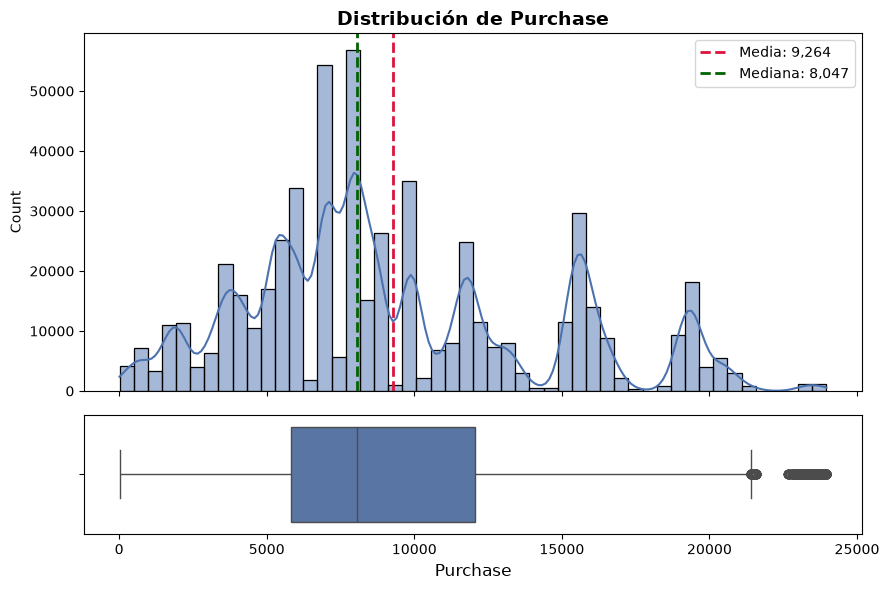

In [13]:
fig, (ax_hist, ax_box) = plt.subplots(
    2, 1,
    figsize=(9, 6),
    sharex=True,                       
    gridspec_kw={"height_ratios": [3, 1]}
)

sns.histplot(data['Purchase'], bins=50, kde=True, color="#4C72B0", ax=ax_hist)
ax_hist.set_title("Distribución de Purchase", fontsize=14, fontweight="bold")
ax_hist.set_xlabel("")

media = data['Purchase'].mean()
mediana = data['Purchase'].median()

ax_hist.axvline(media, color="crimson", linestyle="--", linewidth=2,
                 label=f"Media: {media:,.0f}")
ax_hist.axvline(mediana, color="darkgreen", linestyle="--", linewidth=2,
                 label=f"Mediana: {mediana:,.0f}")

ax_hist.legend(fontsize=10)

sns.boxplot(x=data['Purchase'], color="#4C72B0", ax=ax_box)
ax_box.set_xlabel("Purchase", fontsize=12)

plt.tight_layout()
plt.show()

La distribución de `Purchase` es multimodal, con varios picos bien diferenciados en lugar de una única campana. Esto probablemente se deba a que distintas categorías de producto tienen rangos de precio característicos — hipótesis que se puede confirmar coloreando el histograma por `Product_Category_1` (queda para un análisis posterior).

Los valores que el boxplot marca como outliers se ubican en la cola superior de la distribución. Sin embargo, no se trata de errores de carga: son transacciones reales de montos altos, por lo que no corresponde eliminarlos del análisis.

Además, la media ($9.264) es mayor que la mediana ($8.047), lo cual indica un sesgo positivo (hacia la derecha): la cola de compras de mayor monto "estira" el promedio por encima del valor típico de la distribución.

In [14]:
# ¿Gender es siempre el mismo para un mismo User_ID? (debería serlo, es un dato demográfico fijo del cliente)
data.groupby('User_ID')['Gender'].nunique().value_counts()

Gender
1    5891
Name: count, dtype: int64

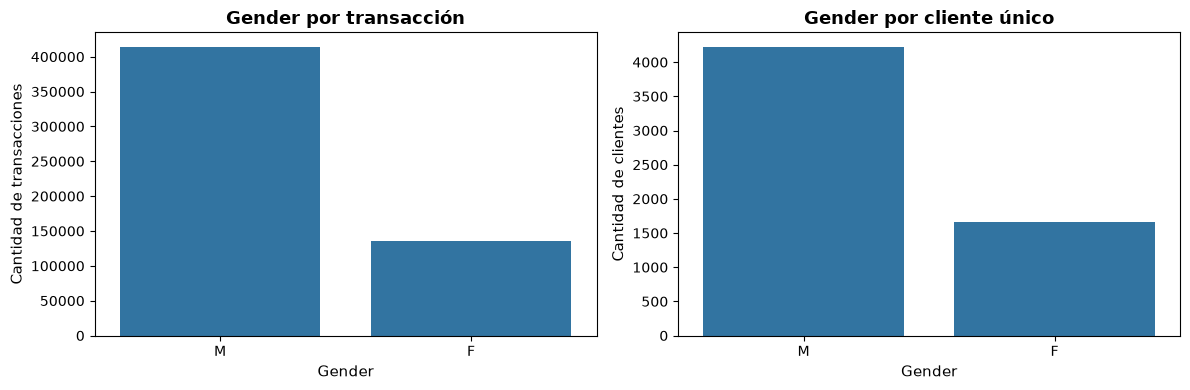

In [15]:
usuarios_unicos = data.drop_duplicates(subset='User_ID')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Panel 1: por transacción (lo que ya tenías)
sns.countplot(x='Gender', data=data,
              order=data['Gender'].value_counts().index, ax=axes[0])
axes[0].set_title('Gender por transacción', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Gender', fontsize=11)
axes[0].set_ylabel('Cantidad de transacciones', fontsize=11)

# Panel 2: por cliente único
sns.countplot(x='Gender', data=usuarios_unicos,
              order=usuarios_unicos['Gender'].value_counts().index, ax=axes[1])
axes[1].set_title('Gender por cliente único', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Gender', fontsize=11)
axes[1].set_ylabel('Cantidad de clientes', fontsize=11)

plt.tight_layout()
plt.show()

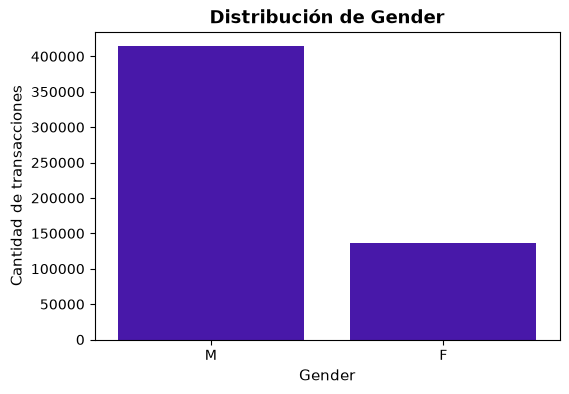

In [16]:
# Gender -> orden por frecuencia (no tiene orden inherente)
plt.figure(figsize=(6, 4))
sns.countplot(x='Gender', data=data,
              order=data['Gender'].value_counts().index, color="#4000C1")
plt.title('Distribución de Gender', fontsize=13, fontweight='bold')
plt.xlabel('Gender', fontsize=11)
plt.ylabel('Cantidad de transacciones', fontsize=11)
plt.show()

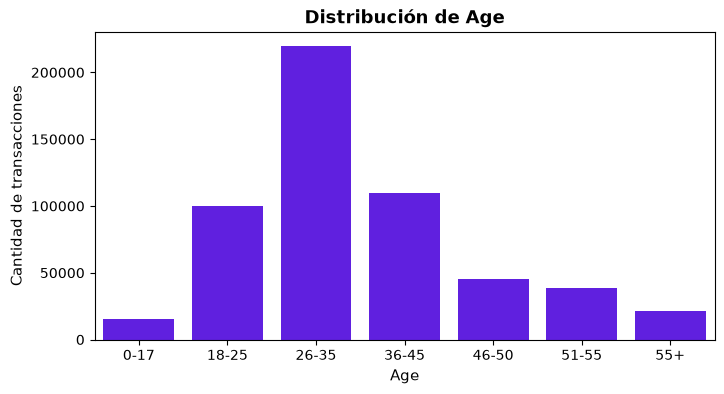

In [17]:
# Age -> orden natural (rangos etarios crecientes)
plt.figure(figsize=(8, 4))
sns.countplot(x='Age', data=data, order=sorted(data['Age'].unique()), color="#5500FF")
plt.title('Distribución de Age', fontsize=13, fontweight='bold')
plt.xlabel('Age', fontsize=11)
plt.ylabel('Cantidad de transacciones', fontsize=11)
plt.show()

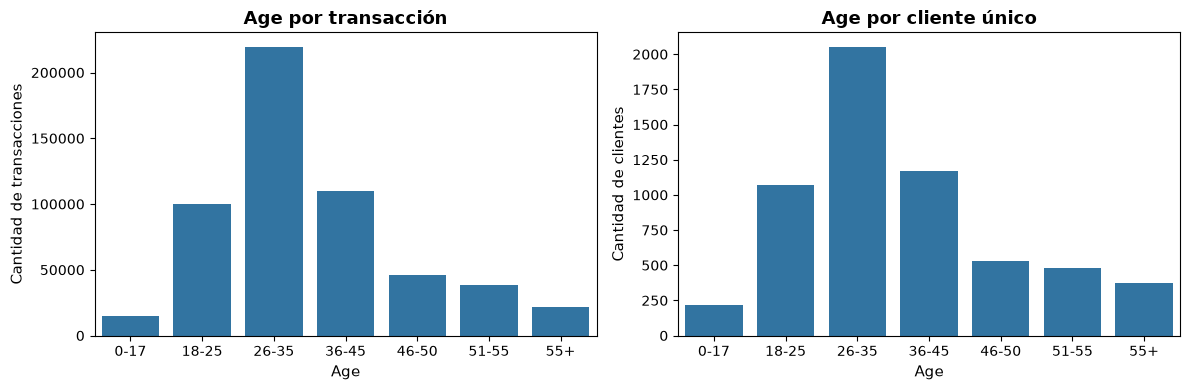

In [18]:
usuarios_unicos = data.drop_duplicates(subset='User_ID')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Panel 1: por transacción (lo que ya tenías)
sns.countplot(x='Age', data=data,
              order=sorted(data['Age'].unique()), ax=axes[0])
axes[0].set_title('Age por transacción', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age', fontsize=11)
axes[0].set_ylabel('Cantidad de transacciones', fontsize=11)

# Panel 2: por cliente único
sns.countplot(x='Age', data=usuarios_unicos,
              order=sorted(usuarios_unicos['Age'].unique()), ax=axes[1])
axes[1].set_title('Age por cliente único', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age', fontsize=11)
axes[1].set_ylabel('Cantidad de clientes', fontsize=11)

plt.tight_layout()
plt.show()

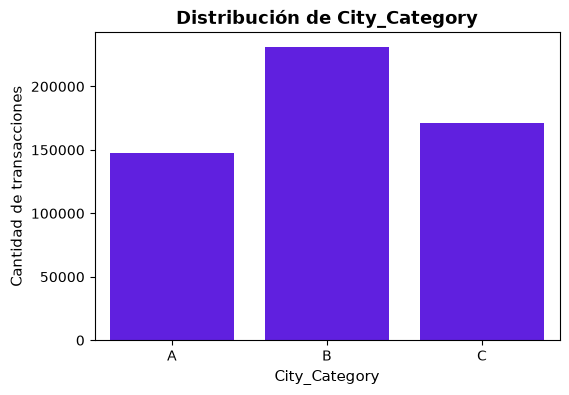

In [19]:
# City_Category -> mantenida alfabética A,B,C (nominal, pero de fácil lectura así)
plt.figure(figsize=(6, 4))
sns.countplot(x='City_Category', data=data, order=['A', 'B', 'C'], color="#5500FF")
plt.title('Distribución de City_Category', fontsize=13, fontweight='bold')
plt.xlabel('City_Category', fontsize=11)
plt.ylabel('Cantidad de transacciones', fontsize=11)
plt.show()

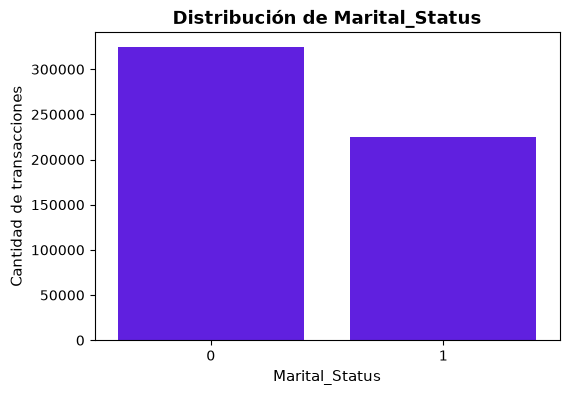

In [20]:
# Marital_Status -> orden por frecuencia (no tiene orden inherente, y no sabemos qué significa cada valor)
plt.figure(figsize=(6, 4))
sns.countplot(x='Marital_Status', data=data,
              order=data['Marital_Status'].value_counts().index, color="#5500FF")
plt.title('Distribución de Marital_Status', fontsize=13, fontweight='bold')
plt.xlabel('Marital_Status', fontsize=11)
plt.ylabel('Cantidad de transacciones', fontsize=11)
plt.show()

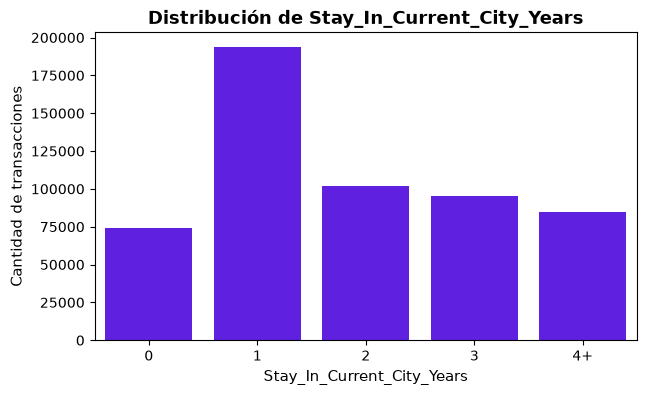

In [21]:
# Stay_In_Current_City_Years -> orden natural (años crecientes)
plt.figure(figsize=(7, 4))
sns.countplot(x='Stay_In_Current_City_Years', data=data,
              order=['0', '1', '2', '3', '4+'], color="#5500FF")
plt.title('Distribución de Stay_In_Current_City_Years', fontsize=13, fontweight='bold')
plt.xlabel('Stay_In_Current_City_Years', fontsize=11)
plt.ylabel('Cantidad de transacciones', fontsize=11)
plt.show()

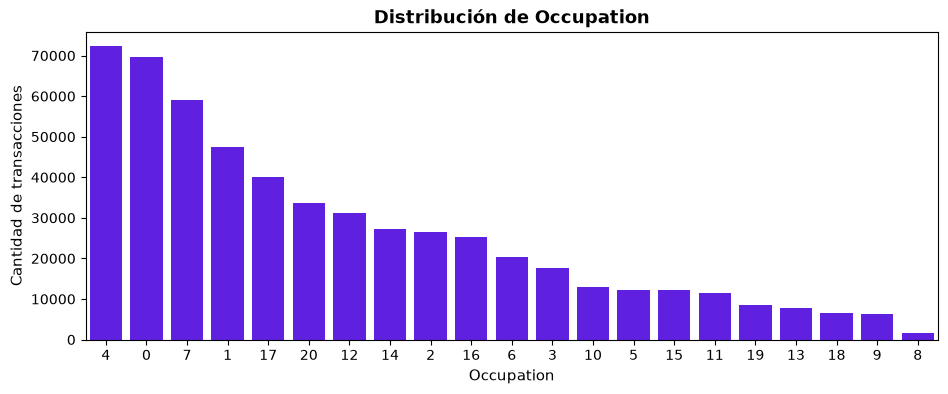

In [22]:
# Occupation -> orden por frecuencia (21 códigos sin significado conocido)
plt.figure(figsize=(11, 4))
sns.countplot(x='Occupation', data=data,
              order=data['Occupation'].value_counts().index, color="#5500FF")
plt.title('Distribución de Occupation', fontsize=13, fontweight='bold')
plt.xlabel('Occupation', fontsize=11)
plt.ylabel('Cantidad de transacciones', fontsize=11)
plt.show()

## c

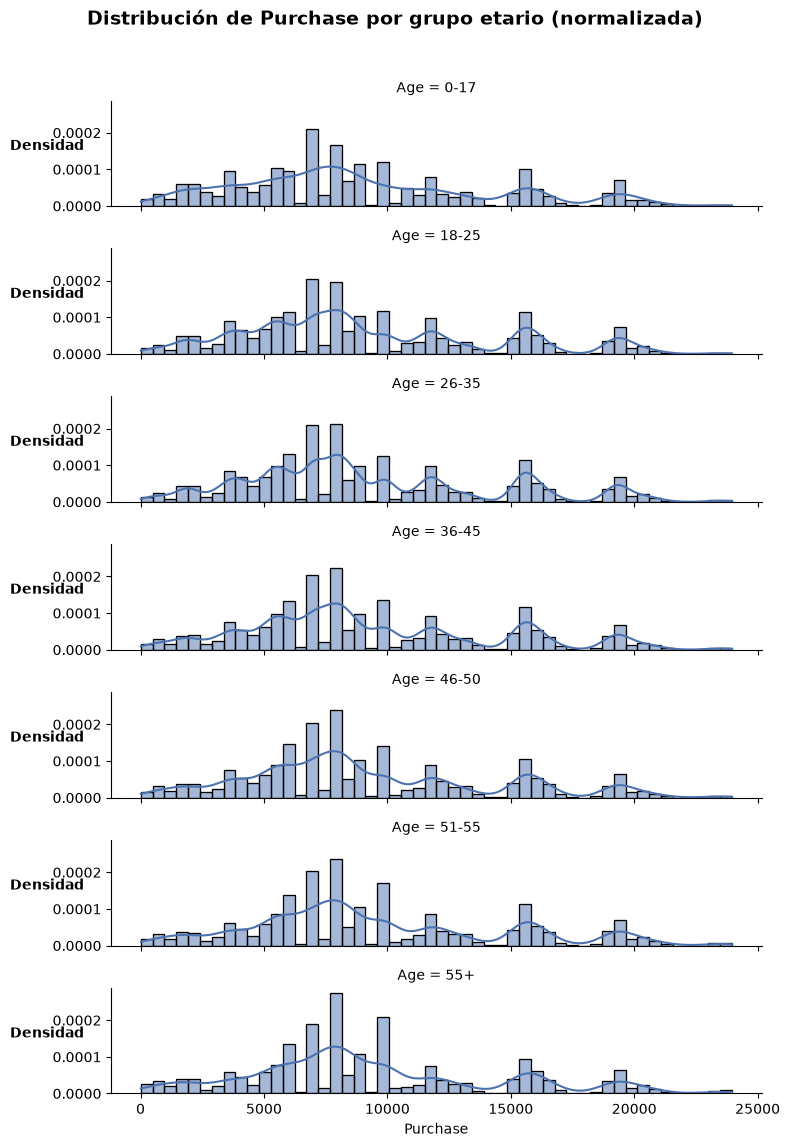

In [23]:
edades_ordenadas = sorted(data['Age'].unique())

g = sns.FacetGrid(data, row='Age', row_order=edades_ordenadas,
                   height=1.6, aspect=5, sharex=True, sharey=True)
g.map(sns.histplot, 'Purchase', bins=50, kde=True, stat='density', color="#4C72B0")

for ax, edad in zip(g.axes.flat, edades_ordenadas):
    ax.set_ylabel(edad, rotation=0, ha='right', fontsize=10, fontweight='bold')

g.set_axis_labels("Purchase", "Densidad")
g.fig.suptitle("Distribución de Purchase por grupo etario (normalizada)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [24]:
gasto_por_usuario = data.groupby('User_ID').agg(
    Purchase_total=('Purchase', 'sum'),
    Age=('Age', 'first')  # Age es fijo por usuario, tomamos cualquiera
).reset_index()

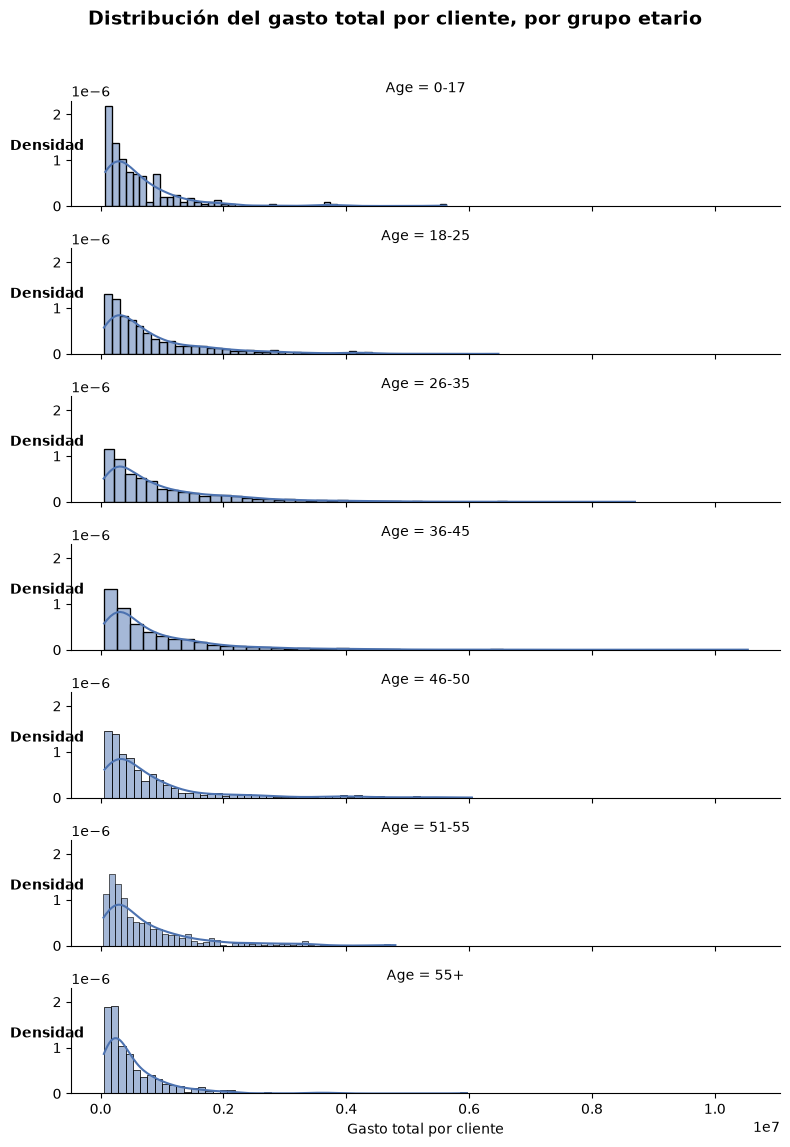

In [25]:
edades_ordenadas = sorted(gasto_por_usuario['Age'].unique())

g = sns.FacetGrid(gasto_por_usuario, row='Age', row_order=edades_ordenadas,
                   height=1.6, aspect=5, sharex=True, sharey=True)
g.map(sns.histplot, 'Purchase_total', bins=50, kde=True, stat='density', color="#4C72B0")

for ax, edad in zip(g.axes.flat, edades_ordenadas):
    ax.set_ylabel(edad, rotation=0, ha='right', fontsize=10, fontweight='bold')

g.set_axis_labels("Gasto total por cliente", "Densidad")
g.fig.suptitle("Distribución del gasto total por cliente, por grupo etario", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

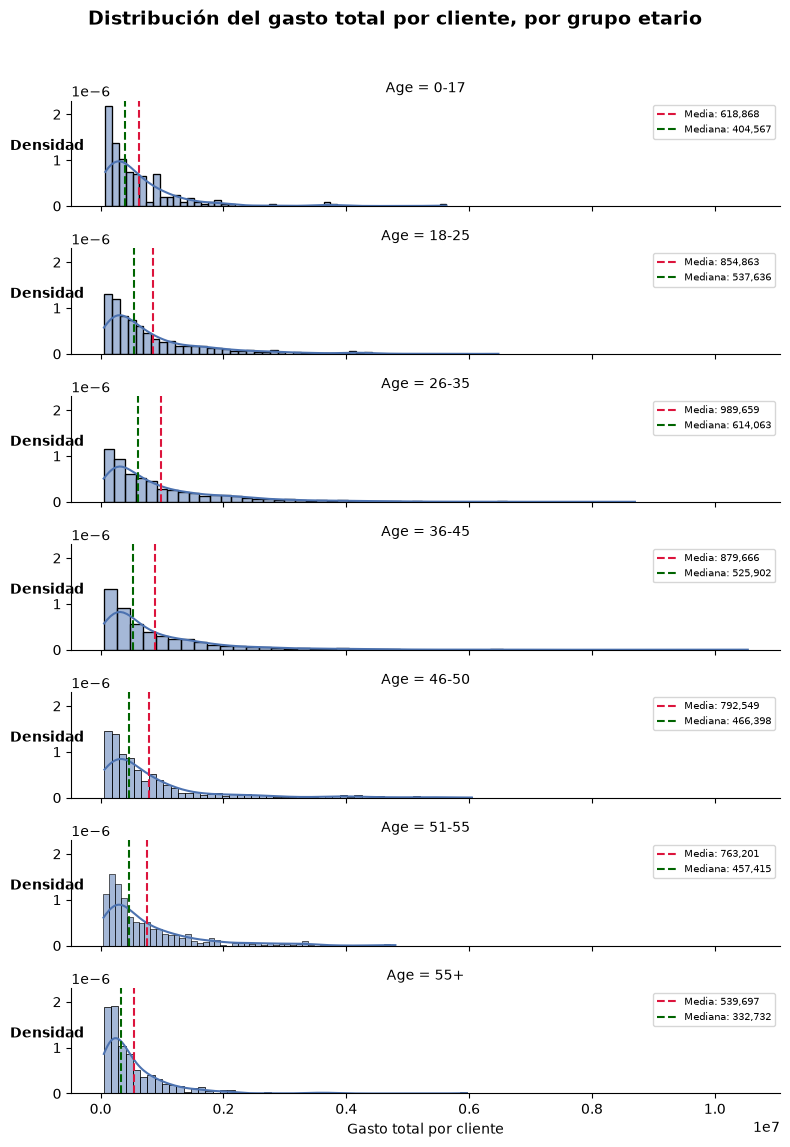

In [26]:
def marcar_media_mediana(x, **kwargs):
    ax = plt.gca()
    media = x.mean()
    mediana = x.median()
    ax.axvline(media, color="crimson", linestyle="--", linewidth=1.5,
               label=f"Media: {media:,.0f}")
    ax.axvline(mediana, color="darkgreen", linestyle="--", linewidth=1.5,
               label=f"Mediana: {mediana:,.0f}")

edades_ordenadas = sorted(gasto_por_usuario['Age'].unique())

g = sns.FacetGrid(gasto_por_usuario, row='Age', row_order=edades_ordenadas,
                   height=1.6, aspect=5, sharex=True, sharey=True)
g.map(sns.histplot, 'Purchase_total', bins=50, kde=True, stat='density', color="#4C72B0")
g.map(marcar_media_mediana, 'Purchase_total')

for ax, edad in zip(g.axes.flat, edades_ordenadas):
    ax.set_ylabel(edad, rotation=0, ha='right', fontsize=10, fontweight='bold')
    ax.legend(fontsize=7, loc='upper right')

g.set_axis_labels("Gasto total por cliente", "Densidad")
g.fig.suptitle("Distribución del gasto total por cliente, por grupo etario", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## d

## e

## f

## g